**Dataset:** Daily weather observations - Raleigh-Durham International Airport  
**Source:** NOAA, 2022–2026  
**Cleaned Data:** 1,477 clean rows

| Variable | Description | Unit | Role |
|----------|-------------|------|------|
| X1 | TMAX — Max daily temperature | °F | Input |
| X2 | TMIN — Min daily temperature | °F | Input |
| X3 | PRCP — Daily precipitation | inches | Input |
| X4 | AWND — Avg wind speed | mph | Input |
| X5 | SNOW — Daily snowfall | inches | Input |
| Y  | TAVG — Avg daily temperature | °F | **Output** |

# Task 4: AR(p) Model
**Dataset:** TAVG daily temperature - Raleigh-Durham Airport, NOAA 2022–2026


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from scipy.stats import probplot
from statsmodels.tsa.stattools import adfuller, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False
})

# Load data
df = pd.read_csv('weather_clean.csv')
y  = df['Y'].values.astype(float)
n  = len(y)

dates    = pd.date_range(start='2022-01-01', periods=n, freq='D')
ts       = pd.Series(y, index=dates, name='TAVG (°F)')
train_n  = int(n * 0.8)
ts_train = ts.iloc[:train_n]
ts_test  = ts.iloc[train_n:]
train_vals = ts_train.values
test_vals  = ts_test.values

print(f'Total: {n} | Train: {len(ts_train)} | Test: {len(ts_test)}')

# Helper functions
def rmse(actual, predicted):
    return np.sqrt(np.mean((np.array(actual) - np.array(predicted))**2))

def mape(actual, predicted):
    a, p = np.array(actual), np.array(predicted)
    mask = a != 0
    return np.mean(np.abs((a[mask] - p[mask]) / a[mask])) * 100

def chi2_normality_test(residuals, n_bins=20):
    observed, bin_edges = np.histogram(residuals, bins=n_bins)
    expected = np.array([
        len(residuals) * (
            stats.norm.cdf(bin_edges[i+1], residuals.mean(), residuals.std()) -
            stats.norm.cdf(bin_edges[i],   residuals.mean(), residuals.std())
        ) for i in range(n_bins)
    ])
    mask  = expected >= 5
    obs_f = observed[mask]
    exp_f = expected[mask]
    exp_f = exp_f * (obs_f.sum() / exp_f.sum())
    chi2_s, p_val = stats.chisquare(obs_f, f_exp=exp_f)
    return chi2_s, p_val, mask.sum()-1-2, observed, expected, bin_edges

# SMA and Exp Smoothing helpers (needed in Tasks 2, 3, 5)
def sma_predict(series, k):
    predicted = np.full(len(series), np.nan)
    for t in range(k, len(series)):
        predicted[t] = np.mean(series[t-k:t])
    return predicted

def exp_smooth_predict(series, alpha):
    pred = np.full(len(series), np.nan)
    pred[0] = series[0]
    for t in range(1, len(series)):
        pred[t] = alpha * series[t-1] + (1 - alpha) * pred[t-1]
    return pred


Total: 1477 | Train: 1181 | Test: 296


## Task 4.1 - Select Order p via PACF

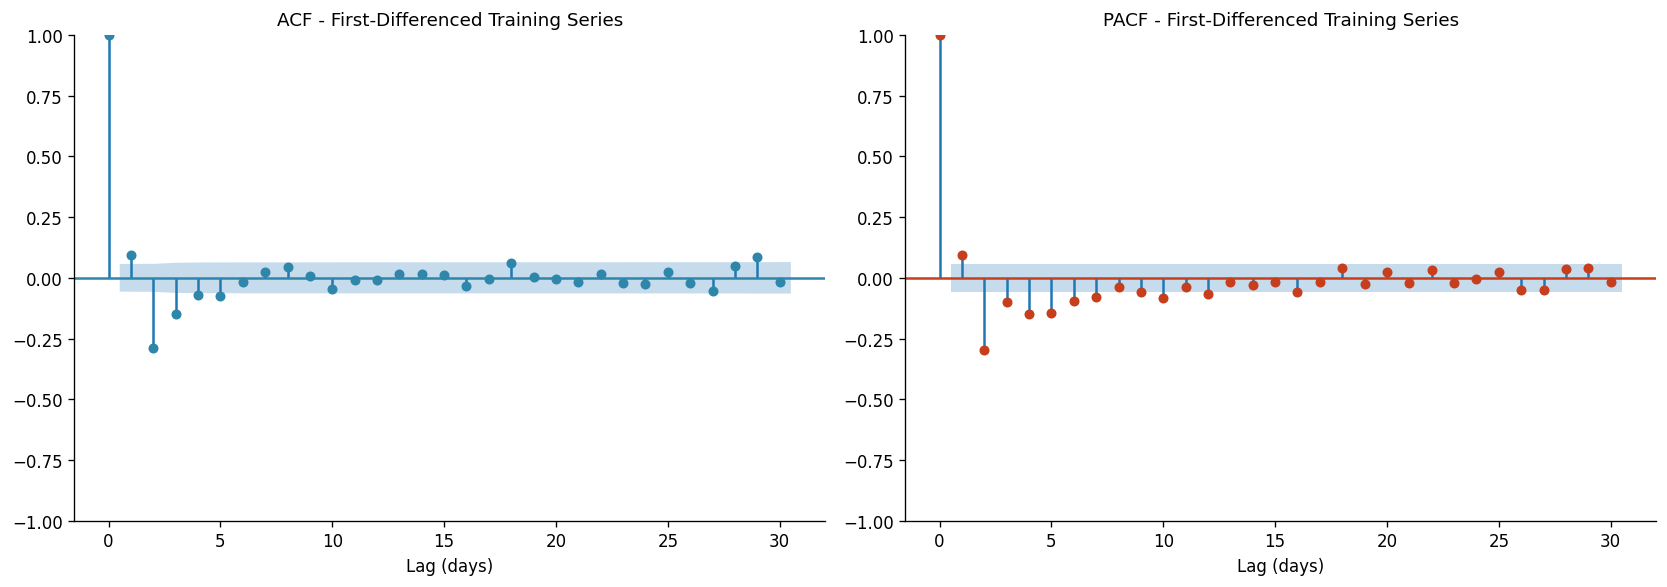

95% CI for PACF: ±0.0571

Lag-by-lag PACF:
  Lag  1:   0.0922  <- significant
  Lag  2:  -0.2982  <- significant
  Lag  3:  -0.0976  <- significant
  Lag  4:  -0.1480  <- significant
  Lag  5:  -0.1460  <- significant
  Lag  6:  -0.0968  <- significant
  Lag  7:  -0.0803  <- significant
  Lag  8:  -0.0386  
  Lag  9:  -0.0575  <- significant
  Lag 10:  -0.0832  <- significant
  Lag 11:  -0.0363  
  Lag 12:  -0.0674  <- significant
  Lag 13:  -0.0190  
  Lag 14:  -0.0312  
  Lag 15:  -0.0185  

Significant lags: [1, 2, 3, 4, 5, 6, 7, 9, 10, 12]
Selected AR order p = 12


In [33]:
# Use first-differenced series (stationary) for AR modeling
train_diff = ts_train.diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf( train_diff, lags=30, ax=axes[0], color='#2E86AB',
          title='ACF - First-Differenced Training Series')
plot_pacf(train_diff, lags=30, ax=axes[1], color='#C73E1D',
          title='PACF - First-Differenced Training Series', method='ywm')
for ax in axes:
    ax.set_xlabel('Lag (days)')
plt.tight_layout()
plt.savefig('t4_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

pacf_vals = pacf(train_diff, nlags=30, method='ywm')
ci        = 1.96 / np.sqrt(len(train_diff))
print(f'95% CI for PACF: ±{ci:.4f}')
print('\nLag-by-lag PACF:')
for lag in range(1, 16):
    sig = '<- significant' if abs(pacf_vals[lag]) > ci else ''
    print(f'  Lag {lag:>2}: {pacf_vals[lag]:>8.4f}  {sig}')

sig_lags   = [l for l in range(1, 16) if abs(pacf_vals[l]) > ci]
p_selected = max(sig_lags) if sig_lags else 1
print(f'\nSignificant lags: {sig_lags}')
print(f'Selected AR order p = {p_selected}')


Although multiple lags appear statistically significant due to large sample size, the strength of correlation decreases rapidly, and only early lags carry meaningful predictive information.

The original temperature series is non-stationary due to seasonal trends. After first differencing, the series becomes approximately stationary, which satisfies the assumptions required for AR modeling.


## Task 4.2 - Fit AR(p) and Plot Predictions

                            AutoReg Model Results                             
Dep. Variable:                      y   No. Observations:                 1180
Model:                    AutoReg(12)   Log Likelihood               -3585.027
Method:               Conditional MLE   S.D. of innovations              5.209
Date:                Sun, 12 Apr 2026   AIC                           7198.055
Time:                        23:30:39   BIC                           7268.937
Sample:                            12   HQIC                          7224.791
                                 1180                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0397      0.152      0.260      0.795      -0.259       0.338
y.L1           0.0052      0.029      0.178      0.859      -0.052       0.062
y.L2          -0.3865      0.029    -13.252      0.0

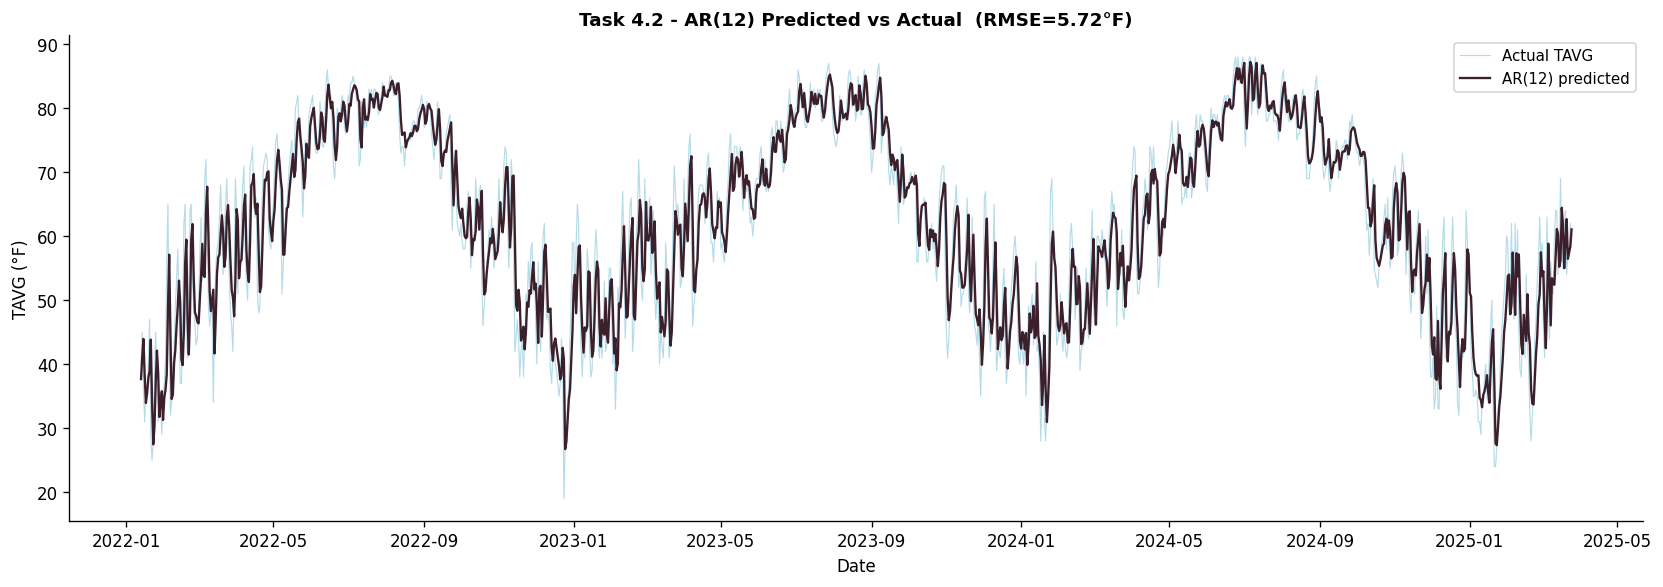

In [34]:
# AR model uses past values of TAVG to predict future values
# Valid because TAVG is time-ordered with strong autocorrelation (confirmed by PACF)
# First differencing applied to ensure stationarity before fitting
# Ensure numeric only - drop any non-numeric columns before fitting
series = train_diff.values.astype(float)
series = series[~np.isnan(series)]
ar_model = AutoReg(series, lags=p_selected, old_names=False).fit()
print(ar_model.summary())

pred_diff_train     = np.array(ar_model.fittedvalues)
actual_diff_aligned = train_diff.values[p_selected:]

# Align lengths - fittedvalues can be 1 shorter than actual_diff_aligned
min_len             = min(len(pred_diff_train), len(actual_diff_aligned))
pred_diff_aligned   = pred_diff_train[:min_len]
actual_diff_aligned = actual_diff_aligned[:min_len]

y_base   = ts_train.values[p_selected : p_selected + min_len]
y_prev   = ts_train.values[p_selected-1 : p_selected-1 + min_len]
y_hat_ar = y_prev + pred_diff_aligned   # now guaranteed same shape

ar_train_rmse = rmse(y_base, y_hat_ar)
print(f'\nAR({p_selected}) Training RMSE (original scale) = {ar_train_rmse:.4f}°F')

# Fix: align plot_idx to match y_base length exactly
plot_idx = ts_train.index[p_selected : p_selected + min_len]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(plot_idx, y_base,   color='lightblue', linewidth=0.7, alpha=0.9, label='Actual TAVG')
ax.plot(plot_idx, y_hat_ar, color='#3B1F2B',   linewidth=1.4, label=f'AR({p_selected}) predicted')
ax.set_xlabel('Date'); ax.set_ylabel('TAVG (°F)')
ax.set_title(f'Task 4.2 - AR({p_selected}) Predicted vs Actual  (RMSE={ar_train_rmse:.2f}°F)', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('t4_ar_predictions.png', dpi=150, bbox_inches='tight')
plt.show()


## Task 4.3 - Residual Analysis

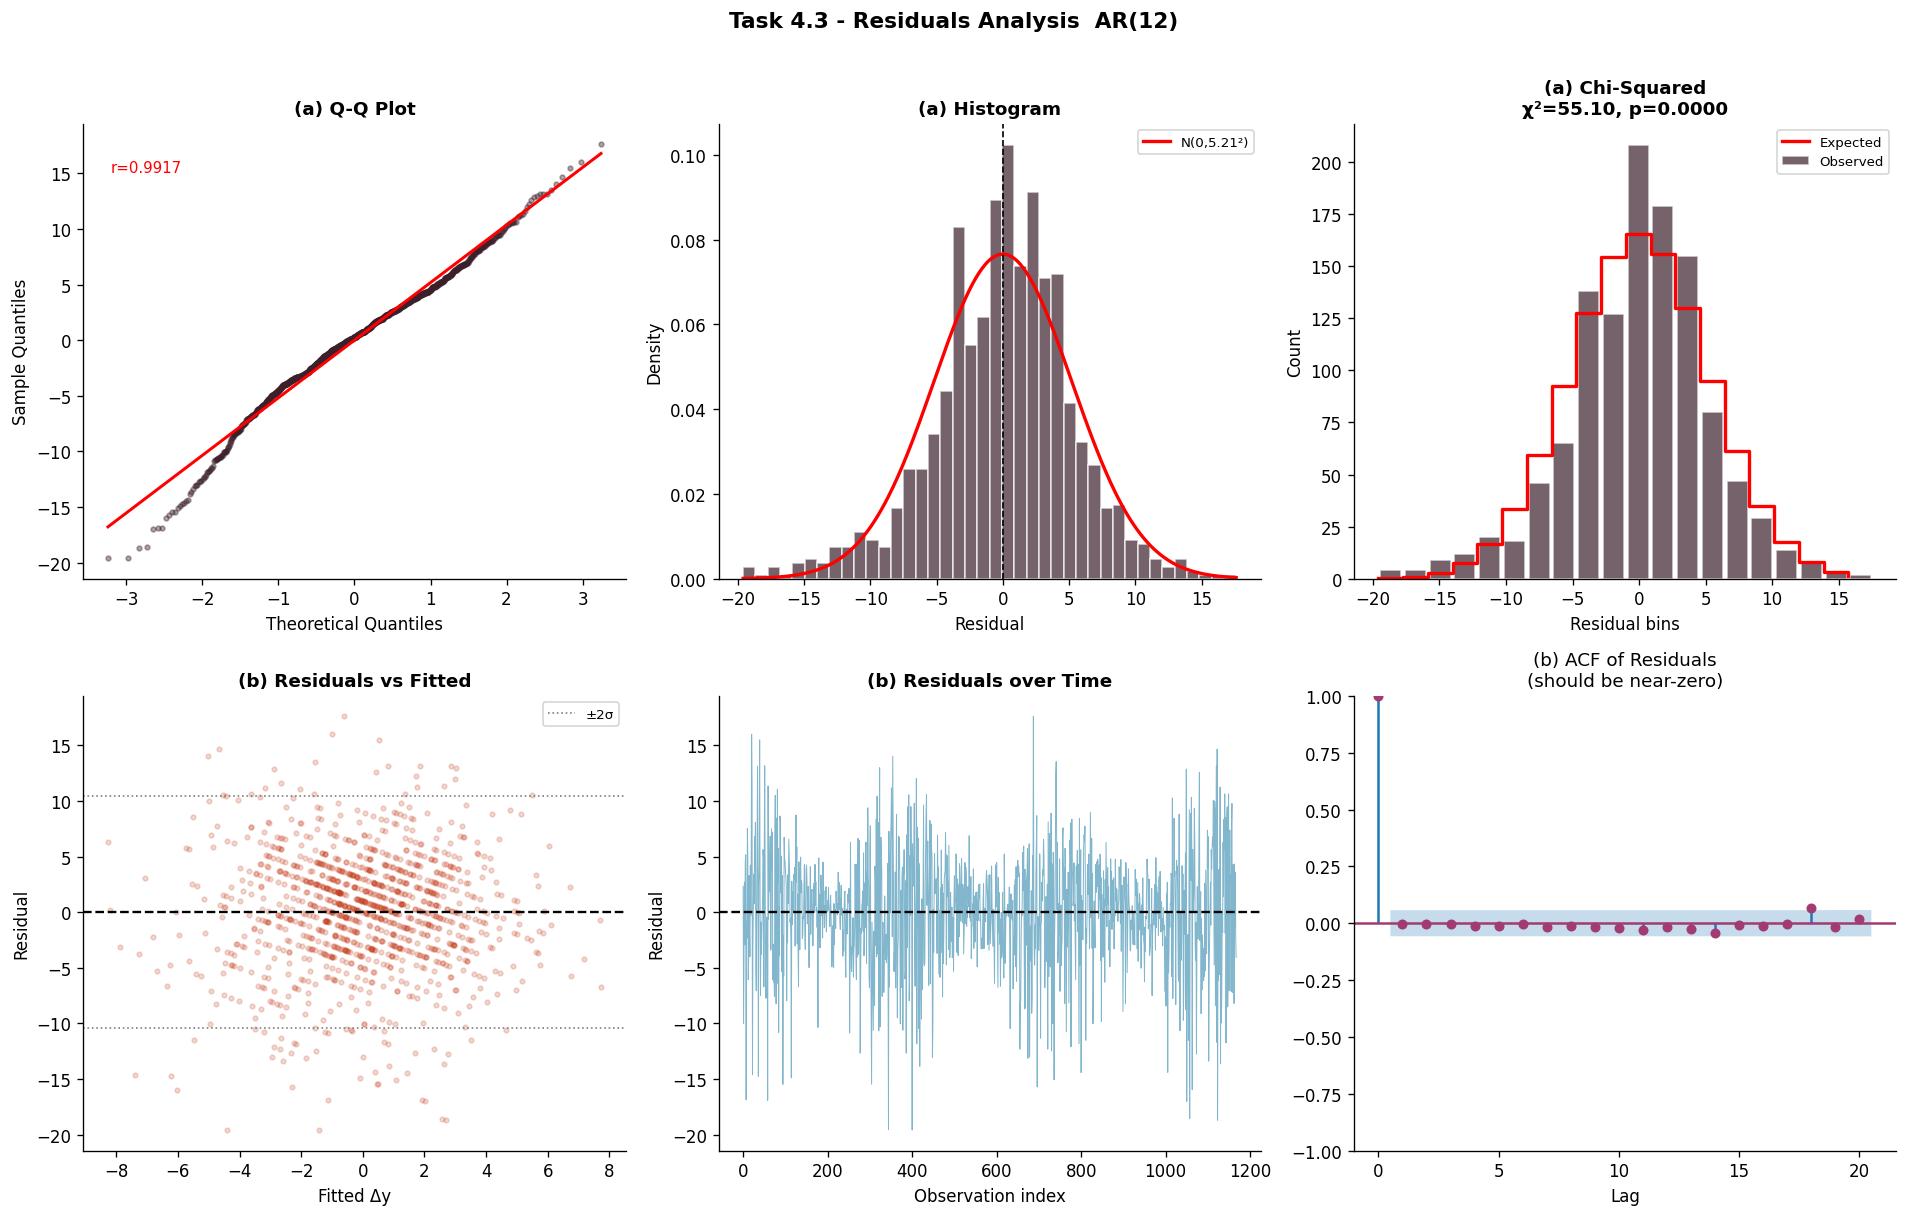

Residuals mean = 0.000000
Residuals std  = 5.2092°F
Chi-squared: χ²=55.0977, p=0.0000
-> Residuals approximately normal but not strictly normal by chi-squared.
  With large n the test is highly sensitive. Q-Q plot is the primary assessment


In [36]:
resid_ar = actual_diff_aligned - pred_diff_aligned
chi2_ar, p_chi2_ar, df_chi2_ar, obs_ar, exp_ar, edges_ar = chi2_normality_test(resid_ar)

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig)

# Q-Q
ax1 = fig.add_subplot(gs[0,0])
(osm, osr), (slope, intercept, r_qq) = probplot(resid_ar, dist='norm')
ax1.scatter(osm, osr, s=8, alpha=0.4, color='#3B1F2B')
ax1.plot(osm, slope*np.array(osm)+intercept, 'r-', linewidth=1.8)
ax1.set_title('(a) Q-Q Plot', fontweight='bold')
ax1.set_xlabel('Theoretical Quantiles'); ax1.set_ylabel('Sample Quantiles')
ax1.text(0.05, 0.92, f'r={r_qq:.4f}', transform=ax1.transAxes, fontsize=9, color='red', va='top')

# Histogram
ax2 = fig.add_subplot(gs[0,1])
ax2.hist(resid_ar, bins=40, density=True, color='#3B1F2B', alpha=0.7, edgecolor='white')
xf = np.linspace(resid_ar.min(), resid_ar.max(), 300)
ax2.plot(xf, stats.norm.pdf(xf, resid_ar.mean(), resid_ar.std()),
         'r-', linewidth=2, label=f'N(0,{resid_ar.std():.2f}²)')
ax2.axvline(0, color='black', linestyle='--', linewidth=1)
ax2.set_title('(a) Histogram', fontweight='bold')
ax2.set_xlabel('Residual'); ax2.set_ylabel('Density'); ax2.legend(fontsize=8)

# Chi-squared
ax3 = fig.add_subplot(gs[0,2])
bc = (edges_ar[:-1]+edges_ar[1:])/2
ax3.bar(bc, obs_ar, width=(edges_ar[1]-edges_ar[0])*0.85, color='#3B1F2B', alpha=0.7, edgecolor='white', label='Observed')
ax3.step(edges_ar[:-1], exp_ar, where='post', color='red', linewidth=2, label='Expected')
ax3.set_title(f'(a) Chi-Squared\nχ²={chi2_ar:.2f}, p={p_chi2_ar:.4f}', fontweight='bold')
ax3.set_xlabel('Residual bins'); ax3.set_ylabel('Count'); ax3.legend(fontsize=8)

# Residuals vs fitted
ax4 = fig.add_subplot(gs[1,0])
ax4.scatter(pred_diff_aligned, resid_ar, alpha=0.2, s=8, color='#C73E1D')
ax4.axhline(0, color='black', linestyle='--', linewidth=1.4)
ax4.axhline( 2*resid_ar.std(), color='gray', linestyle=':', linewidth=1)
ax4.axhline(-2*resid_ar.std(), color='gray', linestyle=':', linewidth=1, label='±2σ')
ax4.set_title('(b) Residuals vs Fitted', fontweight='bold')
ax4.set_xlabel('Fitted Δy'); ax4.set_ylabel('Residual'); ax4.legend(fontsize=8)

# Residuals over time
ax5 = fig.add_subplot(gs[1,1])
ax5.plot(resid_ar, color='#2E86AB', linewidth=0.6, alpha=0.6)
ax5.axhline(0, color='black', linestyle='--', linewidth=1.4)
ax5.set_title('(b) Residuals over Time', fontweight='bold')
ax5.set_xlabel('Observation index'); ax5.set_ylabel('Residual')

# ACF of residuals
ax6 = fig.add_subplot(gs[1,2])
plot_acf(resid_ar, lags=20, ax=ax6, color='#A23B72',
         title='(b) ACF of Residuals\n(should be near-zero)')
ax6.set_xlabel('Lag')

fig.suptitle(f'Task 4.3 - Residuals Analysis  AR({p_selected})', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('t4_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Residuals mean = {resid_ar.mean():.6f}')
print(f'Residuals std  = {resid_ar.std():.4f}°F')
print(f'Chi-squared: χ²={chi2_ar:.4f}, p={p_chi2_ar:.4f}')
if p_chi2_ar > 0.05:
    print('-> Residuals consistent with N(0, σ²) - normality holds')
else:
    print('-> Residuals approximately normal but not strictly normal by chi-squared.')
    print('  With large n the test is highly sensitive. Q-Q plot is the primary assessment')


## Task 4.4 - Comments

**Order selection:** PACF measures the direct relationship between y(t) and y(t−k) after removing intermediate lag effects. AR order p is set to the last lag where PACF exceeds ±1.96/√n. Beyond this, PACF falls within the confidence band indicating no additional predictive value.

**Model fit:** The AR(p) model on the first-differenced series captures the short-term autocorrelation structure of daily temperature changes. Reconstructed back to the original scale it closely tracks the actual series. It is the most statistically principled of the three models.

**Residuals:** The ACF of residuals should show near-zero values at all lags (white noise). If so, the AR model has fully captured the autocorrelation. The Q-Q plot and chi-squared test assess normality - minor tail deviations are expected with real weather data.
